# NLP task 1 –  Text Classification
## NNLM (TF Hub)

## Install Packages

In [1]:
!pip install -q tensorflow-hub nltk wordcloud scikit-learn pandas matplotlib seaborn
print("Packages installed.")

Packages installed.


## Optional – Mount Google Drive

In [2]:
# ── Optional: mount Google Drive to persist downloads across sessions ─────────
# Uncomment the three lines below if you want to save the CSV to Drive.
# from google.colab import drive
# drive.mount('/content/drive')
# ARXIV_CSV = '/content/drive/MyDrive/NLP_Task1/arxiv_dataset.csv'
ARXIV_CSV = 'arxiv_dataset.csv'
print(f"Dataset will be saved/loaded from: {ARXIV_CSV}")


Dataset will be saved/loaded from: arxiv_dataset.csv


## Imports & Setup

In [3]:
import os, time, warnings, re, platform, sys
import xml.etree.ElementTree as ET
from collections import Counter
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
for _pkg in ['stopwords', 'punkt', 'wordnet', 'punkt_tab', 'omw-1.4']:
    nltk.download(_pkg, quiet=True)
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"Hub        : {hub.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

TensorFlow : 2.19.0
Hub        : 0.16.1
GPU        : True


In [4]:
ARXIV_CATEGORIES = {'cs.LG':'Machine Learning', 'astro-ph': 'Astrophysics', 'math.CO': 'Mathematics', 'q-bio':'Biology'}
PAPERS_PER_CLASS = 500
ARXIV_BATCH  = 100
ARXIV_SLEEP  = 3.0
ARXIV_CSV    = 'arxiv_dataset.csv'
MAX_SEQ_LEN  = 200          # used for EDA coverage plot only
BATCH_SIZE   = 64
EPOCHS_NNLM  = 15
TEST_SIZE    = 0.20
RANDOM_SEED  = 42

# Three TF-Hub NNLM models (from week8_text_classification.ipynb)
NNLM_50_URL       = "https://tfhub.dev/google/nnlm-en-dim50/2"
NNLM_50_NORM_URL  = "https://tfhub.dev/google/nnlm-en-dim50-with-normalization/2"
NNLM_128_NORM_URL = "https://tfhub.dev/google/nnlm-en-dim128-with-normalization/2"

NUM_CLASSES  = len(ARXIV_CATEGORIES)
CLASS_NAMES  = list(ARXIV_CATEGORIES.values())
PALETTE      = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
OUT_EDA          = 'outputs/eda'
OUT_NNLM50       = 'outputs/nnlm50'
OUT_NNLM50_NORM  = 'outputs/nnlm50_norm'
OUT_NNLM128_NORM = 'outputs/nnlm128_norm'
OUT_COMPARISON   = 'outputs/comparison'

for _d in [OUT_EDA, OUT_NNLM50, OUT_NNLM50_NORM, OUT_NNLM128_NORM, OUT_COMPARISON]:
    os.makedirs(_d, exist_ok=True)
print(f"Output directories ready.")

Output directories ready.


## arXiv API – Data Collection

In [5]:
ARXIV_API   = "http://export.arxiv.org/api/query"
ATOM_NS     = {'atom': 'http://www.w3.org/2005/Atom'}

def fetch_arxiv(category: str, max_results: int = 500,
                batch_size: int = 100, sleep: float = 3.0) -> list:
    """
    Retrieve paper records from the arXiv API for a given subject category.
    """
    papers = []

    for start in range(0, max_results, batch_size):
        fetch_n = min(batch_size, max_results - start)
        params  = {'search_query': f'cat:{category}', 'start': start, 'max_results': fetch_n, 'sortBy': 'submittedDate', 'sortOrder': 'descending'}
        print(f"[{category}] start={start} | requesting {fetch_n} papers …", end=' ')
        try:
            resp = requests.get(ARXIV_API, params=params, timeout=30)
            resp.raise_for_status()
        except requests.RequestException as e:
            print(f"ERROR – {e}")
            break

        root = ET.fromstring(resp.content)
        entries = root.findall('atom:entry', ATOM_NS)
        print(f"received {len(entries)}")

        if not entries:
            break
        for entry in entries:
            title    = entry.find('atom:title',   ATOM_NS)
            abstract = entry.find('atom:summary', ATOM_NS)
            if title is not None and abstract is not None:
                t = re.sub(r'\s+', ' ', title.text.strip())
                a = re.sub(r'\s+', ' ', abstract.text.strip())
                if len(a) > 80:
                    papers.append({'text': t + '. ' + a, 'label': category})

        if start + batch_size < max_results:
            time.sleep(sleep)
    print(f"{len(papers)} usable papers collected for '{category}'")
    return papers


def build_arxiv_dataset(categories: dict, papers_per_class: int = 500) -> pd.DataFrame:
    """
    Iterate over ARXIV_CATEGORIES, fetch papers for each, and return a
    combined DataFrame with human-readable 'label' column.
    """
    all_papers = []
    for cat_code, cat_label in categories.items():
        print(f"\nFetching '{cat_label}'  (arXiv: {cat_code})")
        papers = fetch_arxiv(cat_code, papers_per_class)
        for p in papers:
            p['label'] = cat_label
        all_papers.extend(papers)

    df = pd.DataFrame(all_papers)
    print(f"\nTotal collected: {len(df):,} papers")
    print(df['label'].value_counts().to_string())
    return df


In [6]:
if os.path.exists(ARXIV_CSV):
    print(f"Loading cached dataset from '{ARXIV_CSV}' …")
    df = pd.read_csv(ARXIV_CSV)
    print(f"{len(df):,} papers loaded.")
else:
    print("No cache found – fetching from arXiv API …")
    print(f"{PAPERS_PER_CLASS * len(ARXIV_CATEGORIES)} papers "
          f"{ARXIV_SLEEP}s sleep"
          f"{int(PAPERS_PER_CLASS/ARXIV_BATCH * len(ARXIV_CATEGORIES) * ARXIV_SLEEP / 60) + 1}"
          f" min estimated")
    df = build_arxiv_dataset(ARXIV_CATEGORIES, PAPERS_PER_CLASS)
    df.to_csv(ARXIV_CSV, index=False)
    print(f"Saved to '{ARXIV_CSV}'")
df.head()


No cache found – fetching from arXiv API …
2000 papers 3.0s sleep2 min estimated

Fetching 'Machine Learning'  (arXiv: cs.LG)
[cs.LG] start=0 | requesting 100 papers … received 100
[cs.LG] start=100 | requesting 100 papers … received 100
[cs.LG] start=200 | requesting 100 papers … received 100
[cs.LG] start=300 | requesting 100 papers … received 100
[cs.LG] start=400 | requesting 100 papers … received 100
500 usable papers collected for 'cs.LG'

Fetching 'Astrophysics'  (arXiv: astro-ph)
[astro-ph] start=0 | requesting 100 papers … received 100
[astro-ph] start=100 | requesting 100 papers … received 100
[astro-ph] start=200 | requesting 100 papers … received 100
[astro-ph] start=300 | requesting 100 papers … received 100
[astro-ph] start=400 | requesting 100 papers … received 100
499 usable papers collected for 'astro-ph'

Fetching 'Mathematics'  (arXiv: math.CO)
[math.CO] start=0 | requesting 100 papers … received 100
[math.CO] start=100 | requesting 100 papers … received 100
[math.CO

,text,label
0,NavTrust: Benchmarking Trustworthiness for Emb...,Machine Learning
1,Spectrally-Guided Diffusion Noise Schedules. D...,Machine Learning
2,Online Learning and Equilibrium Computation wi...,Machine Learning
3,Nemotron-Cascade 2: Post-Training LLMs with Ca...,Machine Learning
4,DriveTok: 3D Driving Scene Tokenization for Un...,Machine Learning


## Exploratory Data Analysis

In [7]:
def eda_overview(df: pd.DataFrame) -> pd.DataFrame:
    """Print statistical summary; add text_len and word_count columns."""
    df = df.copy()
    df['text_len']   = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    print("=" * 55)
    print("DATASET OVERVIEW")
    print("=" * 55)
    print(f"Total papers : {len(df):,}")
    print(f"Domains : {sorted(df['label'].unique())}")
    print(f"Missing values: {df[['text','label']].isnull().sum().to_dict()}")
    print(f"Duplicates : {df.duplicated(subset='text').sum()}")
    print("Class distribution:")
    print(df['label'].value_counts().to_string())
    print("Word count statistics:")
    print(df['word_count'].describe().round(1).to_string())
    return df

df = eda_overview(df)


DATASET OVERVIEW
Total papers : 1,999
Domains : ['Astrophysics', 'Biology', 'Machine Learning', 'Mathematics']
Missing values: {'text': 0, 'label': 0}
Duplicates : 0
Class distribution:
label
Machine Learning    500
Mathematics         500
Biology             500
Astrophysics        499
Word count statistics:
count    1999.0
mean      158.5
std        62.0
min        20.0
25%       110.0
50%       155.0
75%       203.0
max       330.0


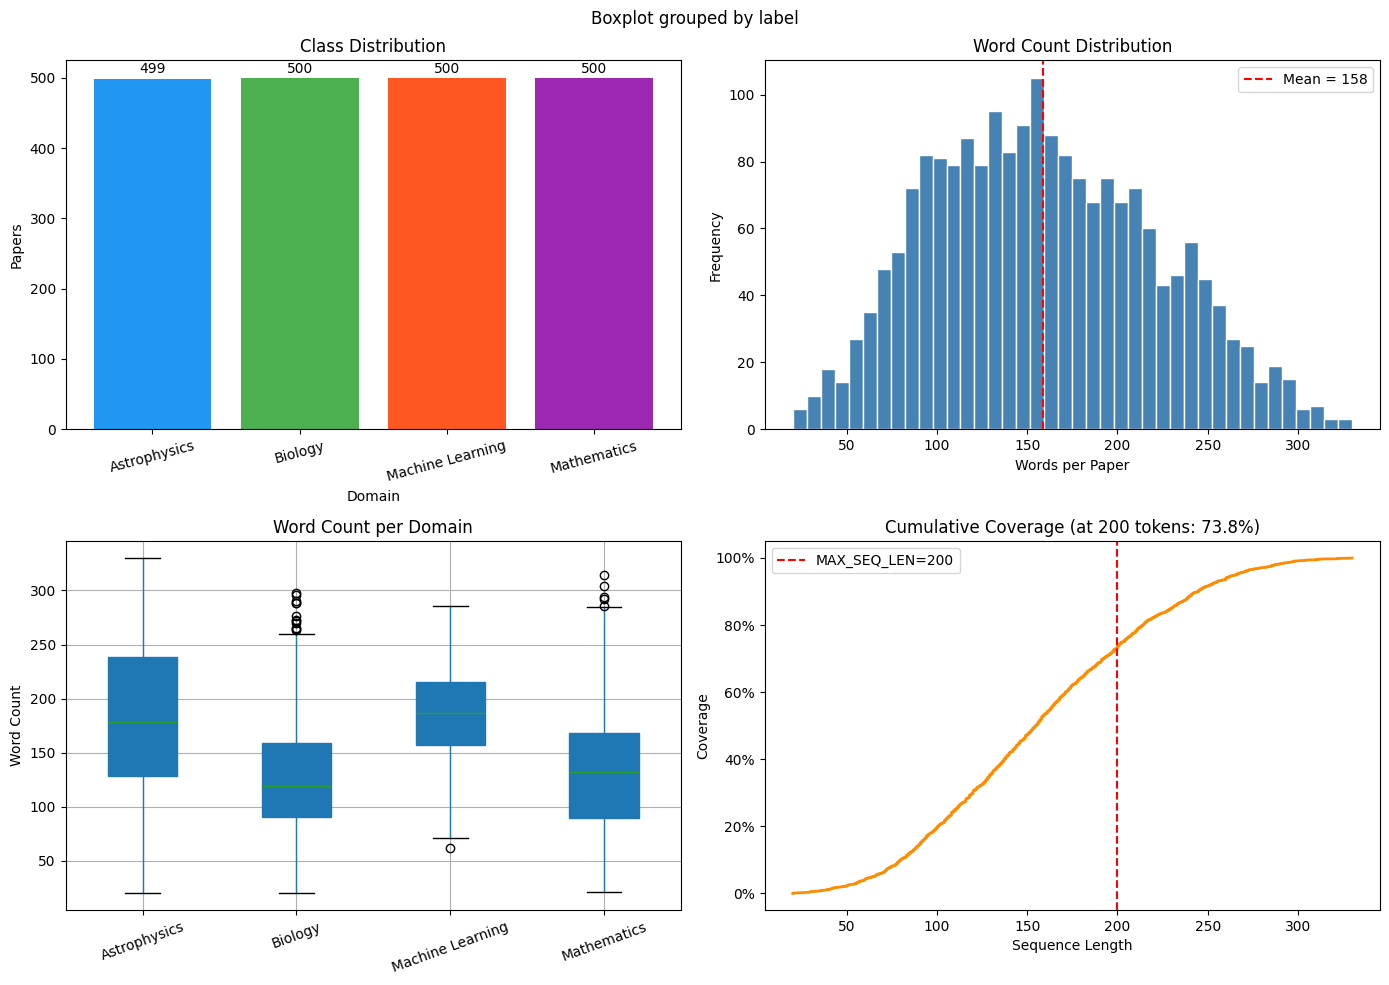

[INFO] Saved 'outputs/eda/eda_overview.png'


In [8]:
def plot_eda(df: pd.DataFrame, palette=PALETTE, save_dir: str = OUT_EDA) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Exploratory Data Analysis – arXiv Dataset", fontsize=15, fontweight='bold')
    counts = df['label'].value_counts().sort_index()
    axes[0,0].bar(counts.index, counts.values, color=palette)
    axes[0,0].set_title("Class Distribution")
    axes[0,0].set_xlabel("Domain"); axes[0,0].set_ylabel("Papers")
    axes[0,0].tick_params(axis='x', rotation=15)
    for bar, v in zip(axes[0,0].patches, counts.values):
        axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(v), ha='center', va='bottom')

    axes[0,1].hist(df['word_count'], bins=40, color='steelblue', edgecolor='white')
    axes[0,1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Mean = {df['word_count'].mean():.0f}")
    axes[0,1].set_title("Word Count Distribution")
    axes[0,1].set_xlabel("Words per Paper"); axes[0,1].set_ylabel("Frequency")
    axes[0,1].legend()
    df.boxplot(column='word_count', by='label', ax=axes[1,0], patch_artist=True)
    axes[1,0].set_title("Word Count per Domain")
    plt.sca(axes[1,0]); plt.xticks(rotation=20)
    axes[1,0].set_xlabel(""); axes[1,0].set_ylabel("Word Count")
    sorted_wc  = np.sort(df['word_count'].values)
    cumulative = np.arange(1, len(sorted_wc)+1) / len(sorted_wc)
    axes[1,1].plot(sorted_wc, cumulative, color='darkorange', lw=2)
    axes[1,1].axvline(MAX_SEQ_LEN, color='red', linestyle='--', label=f"MAX_SEQ_LEN={MAX_SEQ_LEN}")
    cov = (df['word_count'] <= MAX_SEQ_LEN).mean()
    axes[1,1].set_title(f"Cumulative Coverage (at {MAX_SEQ_LEN} tokens: {cov:.1%})")
    axes[1,1].set_xlabel("Sequence Length"); axes[1,1].set_ylabel("Coverage")
    axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    axes[1,1].legend()

    plt.tight_layout()
    fname = os.path.join(save_dir, "eda_overview.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[INFO] Saved '{fname}'")

plot_eda(df)

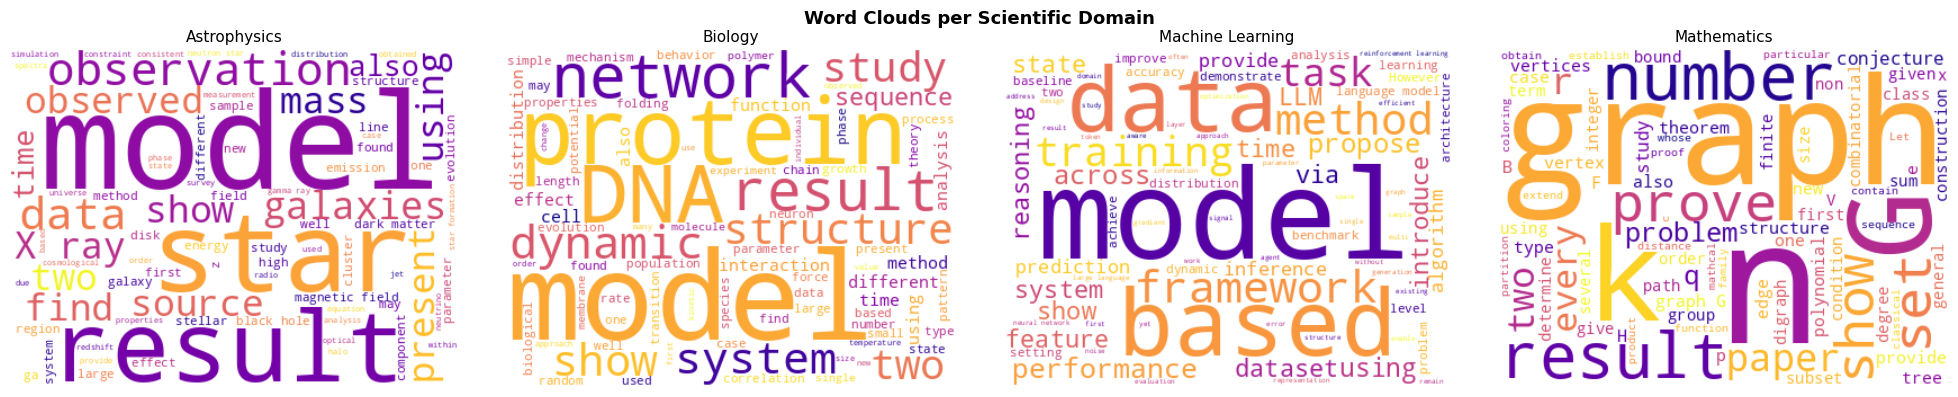

Saved 'outputs/eda/wordclouds.png'


In [9]:
def plot_wordclouds(df: pd.DataFrame, save_dir: str = OUT_EDA) -> None:
    """One word cloud per scientific domain (stopwords removed)."""
    domains = sorted(df['label'].unique())
    stop_words = set(stopwords.words('english'))
    fig, axes = plt.subplots(1, len(domains), figsize=(20, 4))
    fig.suptitle("Word Clouds per Scientific Domain", fontsize=13, fontweight='bold')

    for ax, domain in zip(axes, domains):
        text = " ".join(df.loc[df['label'] == domain, 'text'])
        wc = WordCloud(width=400, height=300, background_color='white', stopwords=stop_words, max_words=80, colormap='plasma').generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(domain, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    fname = os.path.join(save_dir, "wordclouds.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

plot_wordclouds(df)

## 4. Text Preprocessing

In [10]:
_lemmatizer = WordNetLemmatizer()
_stopwords  = set(stopwords.words('english'))

def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\$[^$]*\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [_lemmatizer.lemmatize(t) for t in text.split() if t not in _stopwords and len(t) > 2]
    return " ".join(tokens)

def preprocess_corpus(texts) -> list:
    """Apply preprocess_text to every document; return cleaned list."""
    return [preprocess_text(t) for t in texts]
print("Preprocessing corpus …")
df['clean_text'] = preprocess_corpus(df['text'])
df['clean_wc']   = df['clean_text'].str.split().str.len()
print(f"Avg word count  before : {df['word_count'].mean():.0f}")
print(f"Avg word count  after  : {df['clean_wc'].mean():.0f}")
print("\nSample before:", df['text'].iloc[0][:150])
print("Sample after :", df['clean_text'].iloc[0][:150])

Preprocessing corpus …
Avg word count  before : 158
Avg word count  after  : 94

Sample before: NavTrust: Benchmarking Trustworthiness for Embodied Navigation. There are two major categories of embodied navigation: Vision-Language Navigation (VLN
Sample after : navtrust benchmarking trustworthiness embodied navigation two major category embodied navigation visionlanguage navigation vln agent navigate followin


## Label Encoding & Train/Test Split

In [11]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES= len(le.classes_)
CLASS_NAMES= list(le.classes_)
print(f"Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
_idx = np.arange(len(df))
train_idx, test_idx = train_test_split(_idx, test_size=TEST_SIZE,
                                       stratify=df['label_enc'].values,
                                       random_state=RANDOM_SEED)
X_train_raw  = df['clean_text'].values[train_idx]   # cleaned — for reference
X_test_raw   = df['clean_text'].values[test_idx]
X_train_orig = df['text'].values[train_idx]          # raw text — fed to hub models
X_test_orig  = df['text'].values[test_idx]
y_train     = df['label_enc'].values[train_idx]
y_test      = df['label_enc'].values[test_idx]
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"Train : {len(X_train_raw):,}  |  Test : {len(X_test_raw):,}")

Encoded classes: {'Astrophysics': np.int64(0), 'Biology': np.int64(1), 'Machine Learning': np.int64(2), 'Mathematics': np.int64(3)}
Train : 1,599  |  Test : 400


In [12]:
def build_nnlm_classifier(num_classes: int, nnlm_url: str,
                          trainable: bool = True) -> tf.keras.Model:
    """
    Text classifier using a pre-trained TF-Hub NNLM embedding layer.
    Architecture from week8_text_classification:
        hub_layer → Dense(16, relu) → Dense(num_classes, softmax)
    Uses model subclassing so call() receives real tensors, not KerasTensors,
    avoiding the Keras 3 / TF-Hub symbolic-tensor incompatibility.
    """
    class _NNLMClassifier(tf.keras.Model):
        def __init__(self):
            super().__init__(name="NNLM_Classifier")
            self.nnlm   = hub.KerasLayer(nnlm_url, trainable=trainable,
                                         name="nnlm_embedding")
            self.dense1 = tf.keras.layers.Dense(16, activation="relu",  name="dense1")
            self.out    = tf.keras.layers.Dense(num_classes, activation="softmax",
                                                name="output")

        def call(self, inputs, training=None):
            x = self.nnlm(inputs, training=training)
            x = self.dense1(x,    training=training)
            return self.out(x,    training=training)

    model = _NNLMClassifier()
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def evaluate_model(model, X_test, y_test_cat, y_test_int, class_names: list,
                   model_name: str, save_dir: str = '.') -> dict:
    """Generate predictions, print classification report, plot confusion matrix."""
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc  = accuracy_score(y_test_int, y_pred)
    prec = precision_score(y_test_int, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_int, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_int, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} – Classification Report")
    print(f"{'='*55}")
    print(classification_report(y_test_int, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test_int, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    fname = os.path.join(save_dir, f"cm_{model_name.replace(' ','_').lower()}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")
    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

def plot_history(history, model_name: str, save_dir: str = '.') -> None:
    """Side-by-side accuracy and loss curves for a trained Keras model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Training History – {model_name}", fontsize=13, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = os.path.join(save_dir, f"history_{model_name.replace(' ','_').lower()}.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1)
]

## NNLM Embeddings (TF Hub)

Three pre-trained models from [TensorFlow Hub](https://tfhub.dev/s?module-type=text-embedding) are compared:

| # | Model | Dim | Notes |
|---|-------|-----|-------|
| 1 | `nnlm-en-dim50/2` | 50 | base model |
| 2 | `nnlm-en-dim50-with-normalization/2` | 50 | punctuation removed |
| 3 | `nnlm-en-dim128-with-normalization/2` | 128 | larger embedding |

### Model 1 – NNLM-50 (`nnlm-en-dim50/2`)

In [13]:
print(f"Building NNLM-50 classifier …  URL: {NNLM_50_URL}")
nnlm50_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_50_URL, trainable=True)
nnlm50_clf.summary()

Building NNLM-50 classifier …  URL: https://tfhub.dev/google/nnlm-en-dim50/2


Model: "NNLM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:






+.................................print("\nTraining NNLM-50 classifier …")
t0 = time.time()
nnlm50_history = nnlm50_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm50_clf_time = time.time() - t0
print(f"Training time: {nnlm50_clf_time:.1f}s")
plot_history(nnlm50_history, "NNLM-50", save_dir=OUT_NNLM50)


Training NNLM-50 classifier …
Epoch 1/15


InvalidArgumentError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-packa

In [ ]:
nnlm50_results = evaluate_model(nnlm50_clf, tf.constant(X_test_orig), y_test_cat,
                                y_test, CLASS_NAMES, "NNLM-50", save_dir=OUT_NNLM50)
nnlm50_results['train_time_sec'] = round(nnlm50_clf_time, 2)
print(f"\nNNLM-50 >> Accuracy: {nnlm50_results['accuracy']:.4f}  F1: {nnlm50_results['f1']:.4f}")

### Model 2 – NNLM-50 with Normalization (`nnlm-en-dim50-with-normalization/2`)

In [ ]:
print(f"Building NNLM-50-Norm classifier …  URL: {NNLM_50_NORM_URL}")
nnlm50n_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_50_NORM_URL, trainable=True)
nnlm50n_clf.summary()

In [ ]:
print("\nTraining NNLM-50-Norm classifier …")
t0 = time.time()
nnlm50n_history = nnlm50n_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm50n_clf_time = time.time() - t0
print(f"Training time: {nnlm50n_clf_time:.1f}s")
plot_history(nnlm50n_history, "NNLM-50-Norm", save_dir=OUT_NNLM50_NORM)

In [ ]:
nnlm50n_results = evaluate_model(nnlm50n_clf, tf.constant(X_test_orig), y_test_cat,
                                 y_test, CLASS_NAMES, "NNLM-50-Norm", save_dir=OUT_NNLM50_NORM)
nnlm50n_results['train_time_sec'] = round(nnlm50n_clf_time, 2)
print(f"\nNNLM-50-Norm >> Accuracy: {nnlm50n_results['accuracy']:.4f}  F1: {nnlm50n_results['f1']:.4f}")

### Model 3 – NNLM-128 with Normalization (`nnlm-en-dim128-with-normalization/2`)

In [ ]:
print(f"Building NNLM-128-Norm classifier …  URL: {NNLM_128_NORM_URL}")
nnlm128n_clf = build_nnlm_classifier(NUM_CLASSES, NNLM_128_NORM_URL, trainable=True)
nnlm128n_clf.summary()

In [ ]:
print("\nTraining NNLM-128-Norm classifier …")
t0 = time.time()
nnlm128n_history = nnlm128n_clf.fit(
    tf.constant(X_train_orig), y_train_cat,
    validation_split=0.10,
    epochs=EPOCHS_NNLM,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                       restore_best_weights=True, verbose=1)],
    verbose=1
)
nnlm128n_clf_time = time.time() - t0
print(f"Training time: {nnlm128n_clf_time:.1f}s")
plot_history(nnlm128n_history, "NNLM-128-Norm", save_dir=OUT_NNLM128_NORM)

In [ ]:
nnlm128n_results = evaluate_model(nnlm128n_clf, tf.constant(X_test_orig), y_test_cat,
                                  y_test, CLASS_NAMES, "NNLM-128-Norm", save_dir=OUT_NNLM128_NORM)
nnlm128n_results['train_time_sec'] = round(nnlm128n_clf_time, 2)
print(f"\nNNLM-128-Norm >> Accuracy: {nnlm128n_results['accuracy']:.4f}  F1: {nnlm128n_results['f1']:.4f}")

## Performance Comparison

In [ ]:
def compare_models(results_list: list, save_dir: str = OUT_COMPARISON) -> pd.DataFrame:
    """Print summary table and plot grouped bar chart for all three metrics."""
    df_res  = pd.DataFrame(results_list).set_index('model')
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    df_res[metrics] = df_res[metrics].round(4)

    print("\n" + "="*65)
    print("  MODEL COMPARISON SUMMARY")
    print("="*65)
    print(df_res[metrics + ['train_time_sec']].to_string())
    print("="*65)

    x = np.arange(len(metrics))
    width = 0.25
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, (name, row) in enumerate(df_res.iterrows()):
        ax.bar(x + i*width, [row[m] for m in metrics],
               width, label=name, color=colors[i], alpha=0.87)

    ax.set_title("NNLM-50 vs NNLM-50-Norm vs NNLM-128-Norm – Performance Metrics",
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylabel("Score"); ax.set_ylim(0.5, 1.08)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fname = os.path.join(save_dir, "model_comparison.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")
    return df_res

results_df = compare_models([nnlm50_results, nnlm50n_results, nnlm128n_results])

In [ ]:
def plot_final_comparison(results_list: list, save_dir: str = OUT_COMPARISON) -> None:
    """Three-panel figure: accuracy, weighted F1, training time."""
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    models = [r['model'] for r in results_list]
    acc    = [r['accuracy'] for r in results_list]
    f1     = [r['f1'] for r in results_list]
    times  = [r['train_time_sec'] for r in results_list]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Final Model Comparison – arXiv Classification", fontsize=14, fontweight='bold')
    for ax, vals, title in [(axes[0], acc, "Test Accuracy"),
                            (axes[1], f1,  "Weighted F1"),
                            (axes[2], times, "Train Time (s)")]:
        bars = ax.bar(models, vals, color=colors, alpha=0.87, edgecolor='white')
        ax.set_title(title, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=10)
        for b, v in zip(bars, vals):
            lbl = f"{v:.3f}" if title != "Train Time (s)" else f"{v:.0f}s"
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01, lbl,
                    ha='center', fontsize=9)
        if title != "Train Time (s)":
            ax.set_ylim(0, 1.12)
    plt.tight_layout()
    fname = os.path.join(save_dir, "final_comparison.png")
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved '{fname}'")

plot_final_comparison([nnlm50_results, nnlm50n_results, nnlm128n_results])

## Environment & Timing Summary

In [ ]:
import importlib.metadata
def print_environment() -> None:
    print("=" * 60)
    print("  RUNTIME ENVIRONMENT")
    print("=" * 60)
    print(f"OS     : {platform.system()} {platform.release()}")
    print(f"Python : {sys.version.split()[0]}")
    gpus = tf.config.list_physical_devices('GPU')
    print(f"GPU    : {bool(gpus)}")
    for g in gpus:
        print(f"  {g.name}")
    pkgs = ['tensorflow', 'tensorflow-hub', 'numpy', 'pandas',
            'scikit-learn', 'matplotlib', 'wordcloud', 'nltk']
    print("\n  Key packages:")
    for p in pkgs:
        try:
            v = importlib.metadata.version(p)
        except Exception:
            v = "not found"
        print(f"  {p:<22}: {v}")
    print("=" * 60)

print_environment()

timing = pd.DataFrame({
    'Model'         : ['NNLM-50', 'NNLM-50-Norm', 'NNLM-128-Norm'],
    'Train Time (s)': [nnlm50_results['train_time_sec'],
                       nnlm50n_results['train_time_sec'],
                       nnlm128n_results['train_time_sec']],
    'Epochs'        : [len(nnlm50_history.history['loss']),
                       len(nnlm50n_history.history['loss']),
                       len(nnlm128n_history.history['loss'])],
    'Accuracy'      : [round(nnlm50_results['accuracy'], 4),
                       round(nnlm50n_results['accuracy'], 4),
                       round(nnlm128n_results['accuracy'], 4)],
    'F1 Score'      : [round(nnlm50_results['f1'], 4),
                       round(nnlm50n_results['f1'], 4),
                       round(nnlm128n_results['f1'], 4)]
})
print("\nTIMING AND PERFORMANCE SUMMARY")
print(timing.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(timing['Model'], timing['Train Time (s)'],
              color=['#2196F3', '#4CAF50', '#FF5722'], alpha=0.87, edgecolor='white')
ax.set_title("Training Time per Model", fontsize=12, fontweight='bold')
ax.set_xlabel("Model"); ax.set_ylabel("Seconds")
for b, v in zip(bars, timing['Train Time (s)']):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.0f}s",
            ha='center', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fname = os.path.join(OUT_COMPARISON, "training_time.png")
plt.savefig(fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved '{fname}'"  )